<a href="https://colab.research.google.com/github/SAMALPRASAD1/alzheimer-s-disease-classification/blob/main/VLM_alzheimer" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [2]:
!pip install -q "fsspec==2025.9.0"

In [3]:
import torch
import unsloth
import datasets
import fsspec

print("Unsloth: OK")
print("PyTorch:", torch.__version__)
print("Datasets:", datasets.__version__)
print("fsspec:", fsspec.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: OK
PyTorch: 2.11.0+cu130
Datasets: 4.3.0
fsspec: 2025.9.0
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [4]:
from datasets import load_dataset

dataset = load_dataset("Falah/Alzheimer_MRI")

print(dataset)

README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…): reconstructing file:   0%|          |  0.00B / 22.6MB            

data/train-00000-of-00001-c08a401c53fe53(…): downloading bytes:           |  0.00B            

data/test-00000-of-00001-44110b9df98c558(…): reconstructing file:   0%|          |  0.00B / 5.65MB            

data/test-00000-of-00001-44110b9df98c558(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5120
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
})


In [5]:
print(dataset)
print("\nTrain features:")
print(dataset["train"].features)

print("\nFirst example:")
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5120
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
})

Train features:
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented'])}

First example:
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=L size=128x128 at 0x7AFECD690830>, 'label': 2}


In [6]:
print("Label information:")
print(dataset["train"].features["label"])

Label information:
ClassLabel(names=['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented'])


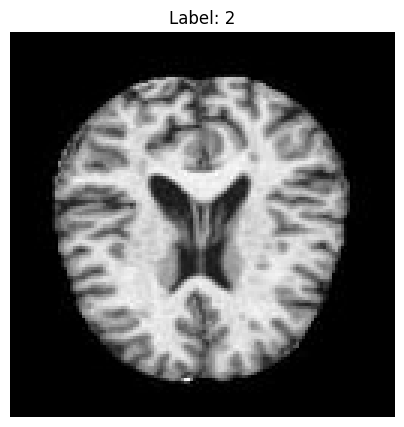

In [7]:
import matplotlib.pyplot as plt

example = dataset["train"][0]

plt.figure(figsize=(5, 5))
plt.imshow(example["image"], cmap="gray")
plt.axis("off")
plt.title(f"Label: {example['label']}")
plt.show()

In [9]:
label_names = dataset["train"].features["label"].names

print("Label mapping:")
for i, name in enumerate(label_names):
    print(i, "→", name)

Label mapping:
0 → Mild_Demented
1 → Moderate_Demented
2 → Non_Demented
3 → Very_Mild_Demented


In [10]:
example = dataset["train"][0]

print("Image type:", type(example["image"]))
print("Label ID:", example["label"])
print("Label name:", label_names[example["label"]])

Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Label ID: 2
Label name: Non_Demented


In [11]:
training_example = {
    "image": example["image"],
    "messages": [
        {
            "role": "user",
            "content": [
                {
                    "type": "image"
                },
                {
                    "type": "text",
                    "text": "Analyze this brain MRI and classify the Alzheimer's disease stage."
                }
            ]
        },
        {
            "role": "assistant",
            "content": [
                {
                    "type": "text",
                    "text": label_names[example["label"]]
                }
            ]
        }
    ]
}

print(training_example)

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=L size=128x128 at 0x7AFECD6ABB10>, 'messages': [{'role': 'user', 'content': [{'type': 'image'}, {'type': 'text', 'text': "Analyze this brain MRI and classify the Alzheimer's disease stage."}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': 'Non_Demented'}]}]}


In [12]:
from collections import Counter

train_counts = Counter(dataset["train"]["label"])
test_counts = Counter(dataset["test"]["label"])

print("TRAIN")
for label_id, count in sorted(train_counts.items()):
    print(f"{label_id} → {label_names[label_id]}: {count}")

print("\nTEST")
for label_id, count in sorted(test_counts.items()):
    print(f"{label_id} → {label_names[label_id]}: {count}")

TRAIN
0 → Mild_Demented: 724
1 → Moderate_Demented: 49
2 → Non_Demented: 2566
3 → Very_Mild_Demented: 1781

TEST
0 → Mild_Demented: 172
1 → Moderate_Demented: 15
2 → Non_Demented: 634
3 → Very_Mild_Demented: 459


In [13]:
import random

instruction_templates = [
    "Analyze this brain MRI and classify the Alzheimer's disease stage.",
    "Based on this MRI, determine the Alzheimer's disease category.",
    "Classify the patient's Alzheimer's stage from this brain MRI.",
    "Examine the MRI and identify the corresponding dementia category."
]

def convert_example(example):
    label = label_names[example["label"]]

    instruction = random.choice(instruction_templates)

    return {
        "image": example["image"],
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": instruction}
                ]
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": label}
                ]
            }
        ]
    }

train_formatted = dataset["train"].map(
    convert_example,
    remove_columns=dataset["train"].column_names
)

test_formatted = dataset["test"].map(
    convert_example,
    remove_columns=dataset["test"].column_names
)

print(train_formatted)
print(test_formatted)

Map:   0%|          | 0/5120 [00:00<?, ? examples/s]

Map:   0%|          | 0/1280 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'messages'],
    num_rows: 5120
})
Dataset({
    features: ['image', 'messages'],
    num_rows: 1280
})


In [14]:
from unsloth import FastVisionModel

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/gemma-3-4b-it",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

==((====))==  Unsloth 2026.9.14: Fast Gemma3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 7.5. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

In [17]:
import unsloth
print("Unsloth version:", unsloth.__version__)

Unsloth version: 2026.9.14


In [19]:
try:
    model = FastVisionModel.get_peft_model(
        model,
        finetune_vision_layers=True,
        finetune_language_layers=True,
        finetune_attention_modules=True,
        finetune_mlp_modules=True,
        r=8,
        lora_alpha=8,
        lora_dropout=0,
        bias="none",
        random_state=3407,
        use_rslora=False,
        loftq_config=None,
        target_modules="all-linear",
    )
except Exception as e:
    import traceback
    traceback.print_exc()

Traceback (most recent call last):
  File "/tmp/ipykernel_1859/1485740542.py", line 2, in <cell line: 0>
    model = FastVisionModel.get_peft_model(
        model,
    ...<11 lines>...
        target_modules="all-linear",
    )
  File "/usr/local/lib/python3.13/dist-packages/unsloth/models/loader.py", line 1658, in get_peft_model
    return FastBaseModel.get_peft_model(model, *args, **kwargs)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/unsloth_zoo/temporary_patches/moe_grouped_modulelist.py", line 390, in wrapper
    result = func(*args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/unsloth/models/vision.py", line 3755, in get_peft_model
    raise RuntimeError("Unsloth: You already added LoRA adapters to your model!")
RuntimeError: Unsloth: You already added LoRA adapters to your model!


In [20]:
from unsloth import FastVisionModel

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/gemma-3-4b-it",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

print("Fresh Gemma 3 model loaded.")

==((====))==  Unsloth 2026.9.14: Fast Gemma3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 7.5. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Fresh Gemma 3 model loaded.


In [21]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=8,
    lora_alpha=8,
    lora_dropout=0,
    bias="none",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

print("LoRA adapters added successfully.")

LoRA adapters added successfully.


In [22]:
processor = tokenizer

print(type(processor))

<class 'transformers.models.gemma3.processing_gemma3.Gemma3Processor'>


In [23]:
example = train_formatted[0]

print(example["messages"])
print(type(example["image"]))
print(example["image"].size)

[{'content': [{'text': None, 'type': 'image'}, {'text': 'Examine the MRI and identify the corresponding dementia category.', 'type': 'text'}], 'role': 'user'}, {'content': [{'text': 'Non_Demented', 'type': 'text'}], 'role': 'assistant'}]
<class 'PIL.JpegImagePlugin.JpegImageFile'>
(128, 128)


In [25]:
from unsloth.trainer import UnslothVisionDataCollator

data_collator = UnslothVisionDataCollator(
    model,
    tokenizer,
    max_seq_length=512,
)

print("Vision data collator created successfully.")

Vision data collator created successfully.


In [26]:
# Small subset for pipeline testing
train_test = train_formatted.select(range(32))

print("Training examples for test run:", len(train_test))
print("Test examples:", len(test_formatted))

Training examples for test run: 32
Test examples: 1280


In [28]:
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from unsloth import is_bf16_supported
from trl import SFTTrainer, SFTConfig

# Enable training mode
FastVisionModel.for_training(model)

# Create the vision data collator
data_collator = UnslothVisionDataCollator(
    model,
    tokenizer
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_test,
    data_collator=data_collator,

    args=SFTConfig(
        output_dir="alzheimer_gemma3_test",

        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,

        max_steps=10,

        learning_rate=2e-4,
        warmup_steps=2,

        logging_steps=1,

        fp16=not is_bf16_supported(),
        bf16=is_bf16_supported(),

        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",

        seed=3407,

        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={
            "skip_prepare_dataset": True
        },

        max_seq_length=2048,

        report_to="none",
    ),
)

print("Trainer created successfully.")

Unsloth: Switching to float32 training since model cannot work with float16
Trainer created successfully.


In [30]:
try:
    trainer_stats = trainer.train()
except Exception as e:
    import traceback
    traceback.print_exc()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 32 | Num Epochs = 2 | Total steps = 10
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 19,248,896 of 4,319,328,368 (0.45% trained)
Traceback (most recent call last):
  File "/tmp/ipykernel_1859/2684029663.py", line 2, in <cell line: 0>
    trainer_stats = trainer.train()
  File "/usr/local/lib/python3.13/dist-packages/unsloth/trainer.py", line 1556, in _train_with_reset
    return _orig_train(*train_args, **train_kwargs)
  File "/content/unsloth_compiled_cache/UnslothSFTTrainer.py", line 116, in wrapper
    output = f(self, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/transformers/trainer.py", line 1424, in train
    return inner_training_loop(
        args=args,
    ...<2 lines>...
        ignore_keys_for_eval=ignore_keys_for_eval,
   

In [31]:
def convert_example_correct(example):
    label = label_names[example["label"]]
    instruction = random.choice(instruction_templates)

    return {
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": example["image"]
                    },
                    {
                        "type": "text",
                        "text": instruction
                    }
                ]
            },
            {
                "role": "assistant",
                "content": [
                    {
                        "type": "text",
                        "text": label
                    }
                ]
            }
        ]
    }

In [32]:
train_formatted = dataset["train"].map(
    convert_example_correct,
    remove_columns=dataset["train"].column_names
)

test_formatted = dataset["test"].map(
    convert_example_correct,
    remove_columns=dataset["test"].column_names
)

print(train_formatted)
print(test_formatted)

Map:   0%|          | 0/5120 [00:00<?, ? examples/s]

Map:   0%|          | 0/1280 [00:00<?, ? examples/s]

Dataset({
    features: ['messages'],
    num_rows: 5120
})
Dataset({
    features: ['messages'],
    num_rows: 1280
})


In [33]:
example = train_formatted[0]

print(example["messages"])

[{'content': [{'image': {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xc0\x00\x0b\x08\x00\x80\x00\x80\x01\x01\x11\x00\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd2\xd3\xd4\xd5\xd6\xd7\xd8\xd9\xda\xe1\xe2\xe3\xe4\xe5\xe6\xe7\xe8\xe9\xea\xf1\xf2\xf3\xf4\xf5\xf6

In [34]:
train_test = train_formatted.select(range(32))

print("Training examples:", len(train_test))

Training examples: 32


In [35]:
from unsloth.trainer import UnslothVisionDataCollator

data_collator = UnslothVisionDataCollator(
    model,
    tokenizer
)

print("Vision collator recreated.")

Vision collator recreated.


In [36]:
from transformers import TrainingArguments
from trl import SFTTrainer, SFTConfig
from unsloth import is_bf16_supported

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_test,
    data_collator=data_collator,

    args=SFTConfig(
        output_dir="alzheimer_gemma3_test",

        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,

        max_steps=10,

        learning_rate=2e-4,
        warmup_steps=2,

        logging_steps=1,

        fp16=not is_bf16_supported(),
        bf16=is_bf16_supported(),

        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",

        seed=3407,

        remove_unused_columns=False,

        dataset_text_field="",
        dataset_kwargs={
            "skip_prepare_dataset": True
        },

        max_seq_length=2048,

        report_to="none",
    ),
)

print("Trainer recreated successfully.")

Unsloth: Switching to float32 training since model cannot work with float16
Trainer recreated successfully.


In [37]:
trainer_stats = trainer.train()

print(trainer_stats)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 32 | Num Epochs = 2 | Total steps = 10
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 19,248,896 of 4,319,328,368 (0.45% trained)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5429: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5429: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5429: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5429: UserWarning: 'has_mkldnn' is d

Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,12.686360
2,12.793013
3,11.024157
4,8.290373
5,6.982767
6,5.946741
7,5.663381
8,5.012346
9,4.410898
10,4.218763


Unsloth: Restored added_tokens_decoder metadata in alzheimer_gemma3_test/checkpoint-10/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in alzheimer_gemma3_test/checkpoint-10.


TrainOutput(global_step=10, training_loss=7.702879905700684, metrics={'train_runtime': 251.0738, 'train_samples_per_second': 0.159, 'train_steps_per_second': 0.04, 'total_flos': 252790702625664.0, 'train_loss': 7.702879905700684, 'epoch': 1.25})


In [38]:
from unsloth import FastVisionModel

# Switch the current model to inference mode
FastVisionModel.for_inference(model)

print("Model switched to inference mode.")

Model switched to inference mode.


In [39]:
test_example = dataset["test"][0]

print("True label:", label_names[test_example["label"]])
print("Image:", test_example["image"].size)

True label: Very_Mild_Demented
Image: (128, 128)


In [40]:
from PIL import Image

image = test_example["image"]

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": (
                    "Analyze this brain MRI and classify the Alzheimer's "
                    "disease stage. Answer with only one of these labels: "
                    "Mild_Demented, Moderate_Demented, Non_Demented, "
                    "Very_Mild_Demented."
                )
            }
        ]
    }
]

input_text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(
    text=input_text,
    images=[image],
    return_tensors="pt"
).to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=20,
    do_sample=False,
)

prediction = tokenizer.decode(
    outputs[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)

print("True label:", label_names[test_example["label"]])
print("Model prediction:", prediction)

True label: Very_Mild_Demented
Model prediction: Based on the provided MRI, the classification is **Non_Demented**.

**Reasoning


In [41]:
from datasets import concatenate_datasets

target_per_class = 724

balanced_parts = []

for label_id in range(len(label_names)):
    class_data = train_formatted.filter(
        lambda x, label_id=label_id:
            label_names[label_id] in x["messages"][1]["content"][0]["text"]
    )

    current_count = len(class_data)

    if current_count == 0:
        continue

    if current_count < target_per_class:
        # Repeat the dataset until we reach the target
        repetitions = target_per_class // current_count
        remainder = target_per_class % current_count

        repeated = concatenate_datasets(
            [class_data] * repetitions
        )

        if remainder > 0:
            repeated = concatenate_datasets(
                [repeated, class_data.select(range(remainder))]
            )

        class_data = repeated
    else:
        class_data = class_data.select(range(target_per_class))

    balanced_parts.append(class_data)

balanced_train = concatenate_datasets(balanced_parts)

balanced_train = balanced_train.shuffle(seed=3407)

print(balanced_train)
print("Total training examples:", len(balanced_train))

Filter:   0%|          | 0/5120 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5120 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5120 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5120 [00:00<?, ? examples/s]

Dataset({
    features: ['messages'],
    num_rows: 2896
})
Total training examples: 2896


In [42]:
from collections import Counter

balanced_counts = Counter(
    example["messages"][1]["content"][0]["text"]
    for example in balanced_train
)

for label in label_names:
    print(label, ":", balanced_counts[label])

Mild_Demented : 224
Moderate_Demented : 724
Non_Demented : 724
Very_Mild_Demented : 1224


In [43]:
from datasets import concatenate_datasets

target_per_class = 724
balanced_parts = []

for label in label_names:

    # Exact match — NOT "in"
    class_data = train_formatted.filter(
        lambda x, label=label:
            x["messages"][1]["content"][0]["text"] == label
    )

    current_count = len(class_data)

    print(f"{label}: original = {current_count}")

    if current_count == 0:
        continue

    # Oversample if necessary
    if current_count < target_per_class:

        repetitions = target_per_class // current_count
        remainder = target_per_class % current_count

        repeated = concatenate_datasets(
            [class_data] * repetitions
        )

        if remainder > 0:
            repeated = concatenate_datasets([
                repeated,
                class_data.select(range(remainder))
            ])

        class_data = repeated

    # Keep exactly target_per_class
    elif current_count > target_per_class:
        class_data = class_data.select(range(target_per_class))

    balanced_parts.append(class_data)

balanced_train = concatenate_datasets(
    balanced_parts
).shuffle(seed=3407)

print("\nBalanced dataset:")
print(balanced_train)
print("Total:", len(balanced_train))

Filter:   0%|          | 0/5120 [00:00<?, ? examples/s]

Mild_Demented: original = 724


Filter:   0%|          | 0/5120 [00:00<?, ? examples/s]

Moderate_Demented: original = 49


Filter:   0%|          | 0/5120 [00:00<?, ? examples/s]

Non_Demented: original = 2566


Filter:   0%|          | 0/5120 [00:00<?, ? examples/s]

Very_Mild_Demented: original = 1781

Balanced dataset:
Dataset({
    features: ['messages'],
    num_rows: 2896
})
Total: 2896


In [44]:
from collections import Counter

balanced_counts = Counter(
    example["messages"][1]["content"][0]["text"]
    for example in balanced_train
)

print("\nFinal class distribution:")

for label in label_names:
    print(f"{label}: {balanced_counts[label]}")


Final class distribution:
Mild_Demented: 724
Moderate_Demented: 724
Non_Demented: 724
Very_Mild_Demented: 724


In [45]:
FastVisionModel.for_training(model)

print("Model ready for training.")

Model ready for training.


In [46]:
data_collator = UnslothVisionDataCollator(
    model,
    tokenizer
)

print("Vision data collator ready.")

Vision data collator ready.


In [47]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bf16_supported

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,

    train_dataset=balanced_train,

    data_collator=data_collator,

    args=SFTConfig(
        output_dir="alzheimer_gemma3_full",

        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,

        num_train_epochs=1,

        learning_rate=2e-4,
        warmup_ratio=0.05,

        logging_steps=10,

        save_strategy="steps",
        save_steps=250,
        save_total_limit=2,

        fp16=not is_bf16_supported(),
        bf16=is_bf16_supported(),

        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",

        seed=3407,

        remove_unused_columns=False,

        dataset_text_field="",
        dataset_kwargs={
            "skip_prepare_dataset": True
        },

        max_seq_length=2048,

        report_to="none",
    ),
)

print("Full Alzheimer VLM trainer created.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Switching to float32 training since model cannot work with float16
Full Alzheimer VLM trainer created.


In [48]:
trainer_stats = trainer.train()

print(trainer_stats)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,896 | Num Epochs = 1 | Total steps = 724
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 19,248,896 of 4,319,328,368 (0.45% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,3.798010
20,1.961363
30,0.795157
40,0.334299
50,0.132169
60,0.152885
70,0.119547
80,0.113822
90,0.114324
100,0.113595


Unsloth: Restored added_tokens_decoder metadata in alzheimer_gemma3_full/checkpoint-250/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in alzheimer_gemma3_full/checkpoint-250.
Unsloth: Restored added_tokens_decoder metadata in alzheimer_gemma3_full/checkpoint-500/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in alzheimer_gemma3_full/checkpoint-500.
Unsloth: Restored added_tokens_decoder metadata in alzheimer_gemma3_full/checkpoint-724/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in alzheimer_gemma3_full/checkpoint-724.


TrainOutput(global_step=724, training_loss=0.19238172648526028, metrics={'train_runtime': 9830.2221, 'train_samples_per_second': 0.295, 'train_steps_per_second': 0.074, 'total_flos': 1.827000864337997e+16, 'train_loss': 0.19238172648526028, 'epoch': 1.0})


In [49]:
print(trainer_stats)

TrainOutput(global_step=724, training_loss=0.19238172648526028, metrics={'train_runtime': 9830.2221, 'train_samples_per_second': 0.295, 'train_steps_per_second': 0.074, 'total_flos': 1.827000864337997e+16, 'train_loss': 0.19238172648526028, 'epoch': 1.0})


In [50]:
import os

print("Training output directory:")
print(os.listdir("alzheimer_gemma3_full"))

Training output directory:
['checkpoint-500', 'README.md', 'checkpoint-724']


In [52]:
import re
import torch

VALID_LABELS = [
    "Mild_Demented",
    "Moderate_Demented",
    "Non_Demented",
    "Very_Mild_Demented",
]

def extract_label(text):
    text = text.strip()

    # Exact match first
    for label in VALID_LABELS:
        if text == label:
            return label

    # Look for a valid label anywhere in the response
    for label in VALID_LABELS:
        if label.lower() in text.lower():
            return label

    # Handle possible spaces instead of underscores
    normalized = text.lower().replace(" ", "_")

    for label in VALID_LABELS:
        if label.lower() in normalized:
            return label

    return "UNKNOWN"


def predict_mri(image):
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text",
                    "text": (
                        "Classify this brain MRI into exactly one of these "
                        "four categories: Mild_Demented, Moderate_Demented, "
                        "Non_Demented, Very_Mild_Demented. "
                        "Answer with only the category name."
                    ),
                },
            ],
        }
    ]

    input_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        text=input_text,
        images=[image],
        return_tensors="pt",
    ).to("cuda")

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False,
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    response = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True,
    ).strip()

    prediction = extract_label(response)

    return prediction, response

In [53]:
for i in range(5):

    example = dataset["test"][i]

    true_label = label_names[example["label"]]

    prediction, raw_response = predict_mri(
        example["image"]
    )

    print(f"\nExample {i + 1}")
    print("True:", true_label)
    print("Predicted:", prediction)
    print("Raw response:", raw_response)


Example 1
True: Very_Mild_Demented
Predicted: Non_Demented
Raw response: Non_Demented

Example 2
True: Mild_Demented
Predicted: Non_Demented
Raw response: Non_Demented

Example 3
True: Non_Demented
Predicted: Non_Demented
Raw response: Non_Demented

Example 4
True: Very_Mild_Demented
Predicted: Non_Demented
Raw response: Non_Demented

Example 5
True: Mild_Demented
Predicted: Non_Demented
Raw response: Non_Demented


In [54]:
from collections import Counter

predictions_100 = []
truths_100 = []

for i in range(100):
    example = dataset["test"][i]

    true_label = label_names[example["label"]]

    prediction, raw_response = predict_mri(example["image"])

    predictions_100.append(prediction)
    truths_100.append(true_label)

    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/100")

print("\nPredicted distribution:")
print(Counter(predictions_100))

print("\nTrue distribution:")
print(Counter(truths_100))

Processed 10/100
Processed 20/100
Processed 30/100
Processed 40/100
Processed 50/100
Processed 60/100
Processed 70/100
Processed 80/100
Processed 90/100
Processed 100/100

Predicted distribution:
Counter({'Non_Demented': 100})

True distribution:
Counter({'Non_Demented': 47, 'Very_Mild_Demented': 39, 'Mild_Demented': 13, 'Moderate_Demented': 1})


TRIED ONE APPROAACH USING VLM(Vision Language Model)
This approach is failing because of a lot of imblance in intial data set . Collision between results are happening and dominated value is predicted


NOW TRING WITH A NEW APPROACH USING ViT(Vision Transformers) for initial classification to remove those imbalance issues during the trainig Like which was a problem in the previous case.

In [55]:
print(dataset)
print(dataset["train"].features)
print(dataset["train"][0]["image"].size)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5120
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
})
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented'])}
(128, 128)


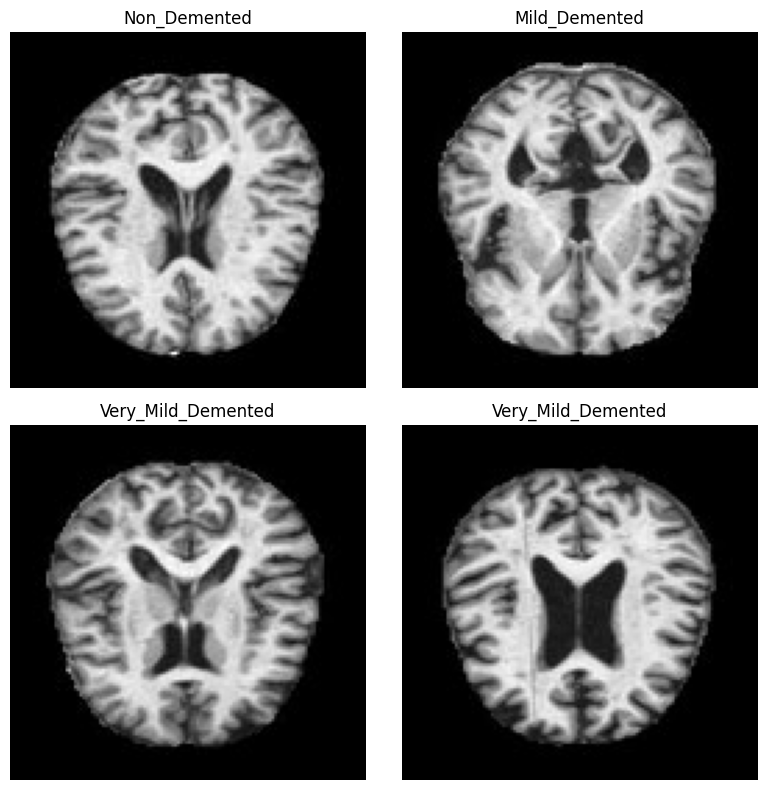

In [56]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    example = dataset["train"][i]

    ax.imshow(example["image"], cmap="gray")
    ax.set_title(label_names[example["label"]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [57]:
from collections import Counter

train_counts = Counter(dataset["train"]["label"])
test_counts = Counter(dataset["test"]["label"])

print("Training distribution:")
for label_id, count in train_counts.items():
    print(label_id, label_names[label_id], count)

print("\nTest distribution:")
for label_id, count in test_counts.items():
    print(label_id, label_names[label_id], count)

Training distribution:
2 Non_Demented 2566
0 Mild_Demented 724
3 Very_Mild_Demented 1781
1 Moderate_Demented 49

Test distribution:
3 Very_Mild_Demented 459
0 Mild_Demented 172
2 Non_Demented 634
1 Moderate_Demented 15


In [58]:
!pip install -q transformers accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [59]:
from transformers import AutoImageProcessor, AutoModelForImageClassification

model_name = "google/vit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(model_name)

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=4,
    id2label={
        0: "Mild_Demented",
        1: "Moderate_Demented",
        2: "Non_Demented",
        3: "Very_Mild_Demented"
    },
    label2id={
        "Mild_Demented": 0,
        "Moderate_Demented": 1,
        "Non_Demented": 2,
        "Very_Mild_Demented": 3
    },
    ignore_mismatched_sizes=True
)

print("Model loaded successfully!")
print("Number of labels:", model.config.num_labels)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded successfully!
Number of labels: 4


In [60]:
def preprocess_example(example):
    image = example["image"].convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    return {
        "pixel_values": inputs["pixel_values"][0],
        "label": example["label"]
    }


train_processed = dataset["train"].map(
    preprocess_example,
    remove_columns=["image"]
)

test_processed = dataset["test"].map(
    preprocess_example,
    remove_columns=["image"]
)

print(train_processed)
print(test_processed)

Map:   0%|          | 0/5120 [00:00<?, ? examples/s]

Map:   0%|          | 0/1280 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'pixel_values'],
    num_rows: 5120
})
Dataset({
    features: ['label', 'pixel_values'],
    num_rows: 1280
})


In [62]:
import torch

pixel_values = torch.tensor(train_processed[0]["pixel_values"])

print("Shape:", pixel_values.shape)
print("Label:", train_processed[0]["label"])

Shape: torch.Size([3, 224, 224])
Label: 2


In [63]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

In [64]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./vit_alzheimer_baseline",

    num_train_epochs=3,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=20,

    fp16=True,

    report_to="none",

    remove_unused_columns=False
)

print("Training configuration created.")

Training configuration created.


In [65]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_processed,
    eval_dataset=test_processed,
    processing_class=processor,
    compute_metrics=compute_metrics,
)

print("Trainer created successfully!")

Trainer created successfully!


In [66]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

GPU available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [67]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,120 | Num Epochs = 3 | Total steps = 960
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 85,801,732 of 85,801,732 (100.00% trained)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [68]:
small_train = train_processed.select(range(200))
small_test = test_processed.select(range(50))

print("Small train:", len(small_train))
print("Small test:", len(small_test))

Small train: 200
Small test: 50


In [69]:
from transformers import TrainingArguments

smoke_args = TrainingArguments(
    output_dir="./vit_smoke_test",

    num_train_epochs=1,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="steps",
    eval_steps=10,

    save_strategy="steps",
    save_steps=10,
    save_total_limit=2,

    logging_steps=5,

    fp16=True,

    report_to="none",

    remove_unused_columns=False
)

print("Smoke-test configuration ready.")

Smoke-test configuration ready.


In [70]:
smoke_trainer = Trainer(
    model=model,
    args=smoke_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    processing_class=processor,
    compute_metrics=compute_metrics,
)

print("Smoke-test Trainer created.")

Smoke-test Trainer created.


In [71]:
smoke_trainer.train()


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 200 | Num Epochs = 1 | Total steps = 13
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 85,801,732 of 85,801,732 (100.00% trained)


Step,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
10,1.057150,1.021162,0.480000,0.489796,0.349206,0.243266
13,1.057150,0.997505,0.460000,0.270202,0.336094,0.258338


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=13, training_loss=1.0305199256310096, metrics={'train_runtime': 43.7319, 'train_samples_per_second': 4.573, 'train_steps_per_second': 0.297, 'total_flos': 1.54986757373952e+16, 'train_loss': 1.0305199256310096, 'epoch': 1.0})

In [72]:
import os

print(os.listdir("./vit_smoke_test"))

['checkpoint-13', 'checkpoint-10']


In [75]:
print(smoke_trainer.callback_handler.callbacks)

[<transformers.trainer_callback.DefaultFlowCallback object at 0x7afe9bda89d0>, <transformers.utils.notebook.NotebookProgressCallback object at 0x7afe9bda88a0>]


In [76]:
from transformers.utils.notebook import NotebookProgressCallback

smoke_trainer.callback_handler.callbacks = [
    cb for cb in smoke_trainer.callback_handler.callbacks
    if not isinstance(cb, NotebookProgressCallback)
]

print("Remaining callbacks:")
print(smoke_trainer.callback_handler.callbacks)

smoke_results = smoke_trainer.evaluate()

print("\nEvaluation results:")
print(smoke_results)

Remaining callbacks:

Evaluation results:
{'eval_loss': 0.9975048899650574, 'eval_accuracy': 0.46, 'eval_macro_precision': 0.27020202020202017, 'eval_macro_recall': 0.33609385783298823, 'eval_macro_f1': 0.2583379399299797, 'eval_runtime': 6.013, 'eval_samples_per_second': 8.315, 'eval_steps_per_second': 0.665, 'epoch': 1.0}


In [ ]:
from google.colab import drive

drive.mount('/content/drive')